# Notebook 04 — Modeling: Disaster-Level Classification (Strategic / Budget Forecasting)
**Label:** `funding_tier` — 4 classes based on total PA obligations per disaster:
- 0 = Minor (<$1M) | 1 = Moderate ($1M–$50M) | 2 = Major ($50M–$500M) | 3 = Catastrophic (>$500M)

**Use case:** FEMA budget planning — classify total spend tier before projects are filed.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
sys.path.append('../')
from utils import classification_metrics, time_based_split, DISASTER_LABELS

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone

PROCESSED = '../data/processed/'
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Disaster-level shape:', disas.shape)
print('Target distribution:\n', disas['funding_tier'].value_counts().sort_index())

Disaster-level shape: (1766, 20)
Target distribution:
 funding_tier
0     168
1    1301
2     229
3      68
Name: count, dtype: int64


## 4.1 Define Features & Target


In [ ]:
CAT_FEATURES = ['incidentType', 'stateAbbreviation', 'incident_season']
NUM_FEATURES = [
    'declaration_lag_days',
    'incident_duration_days',
    'n_counties',
    'prior_disasters_5yr',
    'population',
    'median_income',
    'poverty_rate',
    'risk_score',
]
# n_projects deliberately excluded: the number of PA applications is only known
# 12-18 months after declaration — including it would break prospective validity.
TARGET = 'funding_tier'

CAT_FEATURES = [c for c in CAT_FEATURES if c in disas.columns]
NUM_FEATURES = [c for c in NUM_FEATURES if c in disas.columns]
FEATURES     = CAT_FEATURES + NUM_FEATURES

df_model = disas[FEATURES + [TARGET, 'incident_year']].dropna(subset=[TARGET])
df_model[TARGET] = df_model[TARGET].astype(int)
print(f'Modeling rows: {len(df_model):,}  |  Features: {len(FEATURES)}')
print('Categorical:', CAT_FEATURES)
print('Numeric:    ', NUM_FEATURES)
print('\nClass distribution:')
for t, n in df_model[TARGET].value_counts().sort_index().items():
    print(f'  Tier {t} {DISASTER_LABELS[t]:<28} {n:>5,}  ({100*n/len(df_model):.1f}%)')

## 4.2 Time-Based Train / Validation / Test Split
Three-way temporal split — no data from a later period ever informs an earlier one:
- **Train (pre-2016):** fit all models
- **Validation (2016–2017):** model selection — pick best algorithm without touching test
- **Test (2018+):** final reported metrics — touched only once

In [ ]:
VALIDATION_YEAR = 2016
SPLIT_YEAR      = 2018

train = df_model[df_model['incident_year'] <  VALIDATION_YEAR]
val   = df_model[(df_model['incident_year'] >= VALIDATION_YEAR) &
                 (df_model['incident_year'] <  SPLIT_YEAR)]
test  = df_model[df_model['incident_year'] >= SPLIT_YEAR]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train : {len(X_train):,}  ({train["incident_year"].min()}–{train["incident_year"].max()})')
print(f'Val   : {len(X_val):,}    ({val["incident_year"].min()}–{val["incident_year"].max()})')
print(f'Test  : {len(X_test):,}   ({test["incident_year"].min()}–{test["incident_year"].max()})')

## 4.3 Preprocessing Pipeline


In [21]:
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
])
print('Preprocessor defined.')


Preprocessor defined.


## 4.4 Train & Evaluate All Models


In [ ]:
TARGET_NAMES = [DISASTER_LABELS[i] for i in range(4)]

models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression':   LogisticRegression(max_iter=1000, class_weight='balanced',
                                                random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results_disaster = {}   # test metrics — final reporting
results_val      = {}   # val  metrics — model selection

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    # Validation — model selection
    val_preds = pipe.predict(X_val)
    m_val = classification_metrics(y_val.values, val_preds, label=name,
                                   target_names=TARGET_NAMES)
    results_val[name] = {**m_val, 'pipeline': pipe, 'preds': val_preds}

    # Test — final reporting only
    test_preds = pipe.predict(X_test)
    m_test = classification_metrics(y_test.values, test_preds, label=name,
                                    target_names=TARGET_NAMES)
    m_test['pipeline'] = pipe
    m_test['preds']    = test_preds
    results_disaster[name] = m_test

    print(f'{name:<30}  val F1={m_val["F1_weighted"]:.4f}  |  test F1={m_test["F1_weighted"]:.4f}')

## 4.7 Results Summary Table
Model selection uses **validation F1** (2016–2017). Test F1 (2018+) is reported for final evaluation only.

In [ ]:
summary = pd.DataFrame([
    {
        'Model':    name,
        'Val F1':   round(results_val[name]['F1_weighted'], 4) if name in results_val else '-',
        'Test F1':  round(results_disaster[name]['F1_weighted'], 4),
        'Test Acc': round(results_disaster[name]['Accuracy'], 4),
    }
    for name in results_disaster
]).set_index('Model')
display(summary)

# Per-class breakdown for val-selected best model
best_name = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
print(f'\nPer-class metrics — {best_name} (test set):')
report_df = pd.DataFrame(
    classification_report(
        y_test,
        results_disaster[best_name]['preds'],
        target_names=TARGET_NAMES,
        zero_division=0,
        output_dict=True
    )
).T.round(3)
display(report_df)

## 4.8 Feature Importances & Confusion Matrix

In [ ]:
best_name  = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
best_pipe  = results_disaster[best_name]['pipeline']
best_model = best_pipe.named_steps['model']
best_pre   = best_pipe.named_steps['pre']

ohe_names = best_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names  = list(ohe_names) + NUM_FEATURES

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=all_names)
    importances.nlargest(20).sort_values().plot(
        kind='barh', figsize=(10, 6),
        title=f'Top 20 Feature Importances — {best_name}',
        color='steelblue'
    )
    plt.tight_layout()
    plt.savefig('../data/processed/feature_importance_disaster.png', dpi=150)
    plt.show()

# Confusion matrix — val-selected best model on test set
cm = confusion_matrix(y_test, results_disaster[best_name]['preds'])
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (Disaster-Level, Test Set)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_disaster.png', dpi=150)
plt.show()

## 4.9 Save Best Pipeline

In [ ]:
best_name = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
print(f'Best model (val F1):  {best_name}')
print(f'  Val  F1_weighted : {results_val[best_name]["F1_weighted"]:.4f}')
print(f'  Test F1_weighted : {results_disaster[best_name]["F1_weighted"]:.4f}')

with open(PROCESSED + 'best_disaster_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':     results_disaster[best_name]['pipeline'],
        'X_test':       X_test,
        'y_test':       y_test,
        'preds':        results_disaster[best_name]['preds'],
        'val_f1':       results_val[best_name]['F1_weighted'],
        'test_f1':      results_disaster[best_name]['F1_weighted'],
        'features':     FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'target_names': TARGET_NAMES,
        'model_name':   best_name,
        'level':        'disaster',
    }, f)
print('Saved best_disaster_model.pkl')

## 4.6 Feature Importances — Random Forest


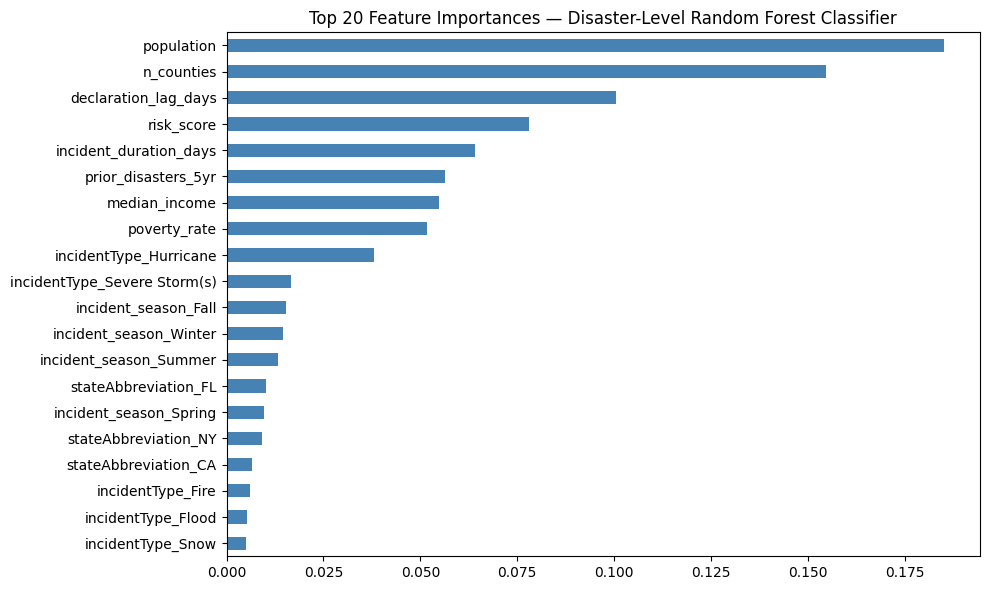

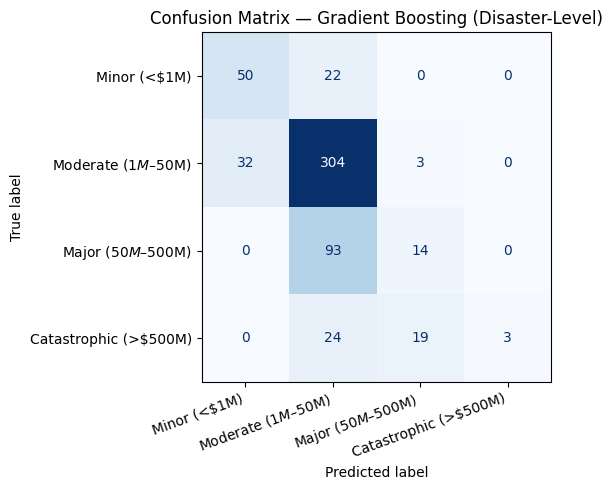

In [26]:
rf_pipe  = results_disaster['Random Forest']['pipeline']
rf_model = rf_pipe.named_steps['model']
rf_pre   = rf_pipe.named_steps['pre']

ohe_names = rf_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names = list(ohe_names) + NUM_FEATURES

importances = pd.Series(rf_model.feature_importances_, index=all_names)
importances.nlargest(20).sort_values().plot(
    kind='barh', figsize=(10, 6),
    title='Top 20 Feature Importances — Disaster-Level Random Forest Classifier',
    color='steelblue'
)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_disaster.png', dpi=150)
plt.show()

# Confusion matrix for best model
best_name = max(results_disaster, key=lambda k: results_disaster[k]['F1_weighted'])
cm = confusion_matrix(y_test, results_disaster[best_name]['preds'])
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (Disaster-Level)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_disaster.png', dpi=150)
plt.show()

## 4.7 Save Best Pipeline


In [27]:
# Select by validation F1 — never by test F1
best_name = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
print(f'Best model (val F1):  {best_name}')
print(f'  Val  F1_weighted : {results_val[best_name]["F1_weighted"]:.4f}')
print(f'  Test F1_weighted : {results_disaster[best_name]["F1_weighted"]:.4f}')

with open(PROCESSED + 'best_disaster_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':     results_disaster[best_name]['pipeline'],
        'X_test':       X_test,
        'y_test':       y_test,
        'preds':        results_disaster[best_name]['preds'],
        'features':     FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'target_names': TARGET_NAMES,
        'model_name':   best_name,
        'level':        'disaster',
    }, f)
print('Saved best_disaster_model.pkl')

Best model (val F1):  GradBoosting (Tuned)
  Val  F1_weighted : 0.7254
  Test F1_weighted : 0.5847
Saved best_disaster_model.pkl
